In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='age', ylabel='charges'>

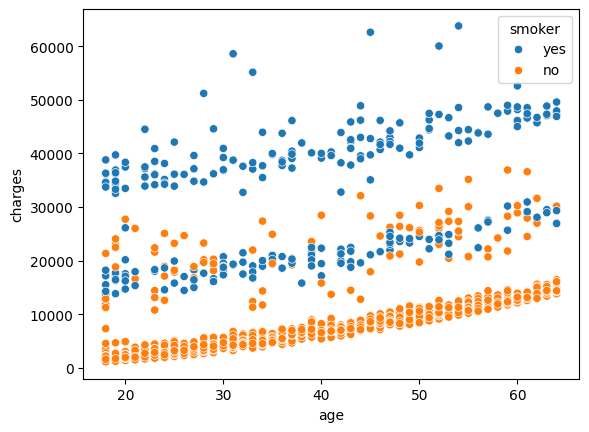

In [4]:
sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker'
)

<Axes: xlabel='bmi', ylabel='charges'>

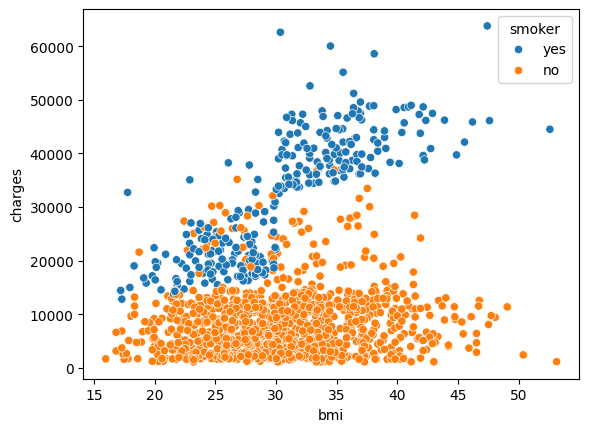

In [5]:
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker'
)

In [6]:
X=df.drop(columns=['charges','region'])
y=df['charges']

In [7]:
X.head()

,age,sex,bmi,children,smoker
0,19,female,27.900,0,yes
1,18,male,33.770,1,no
2,28,male,33.000,3,no
3,33,male,22.705,0,no
4,32,male,28.880,0,no


In [8]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [9]:
X['sex']=X['sex'].map({'female':1,'male':0})
X['smoker']=X['smoker'].map({'yes':1,'no':0})

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_preds=model.predict(X_test)

In [13]:
y_preds

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [14]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_preds)
print(r2)

0.7811302113434095


In [15]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1070, 5)
(1070,)
(268, 5)
(268,)


In [20]:
X=df.drop(columns=['charges'])
y=df['charges']
X=pd.get_dummies(X,columns=['region'],drop_first=True
                 ,dtype=int)
X['sex']=X['sex'].map({'female':1,'male':0})
X['smoker']=X['smoker'].map({'yes':1,'no':0})

In [17]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,0,1
1,18,0,33.770,1,0,0,0,1,0
2,28,0,33.000,3,0,0,0,1,0
3,33,0,22.705,0,0,0,1,0,0
4,32,0,28.880,0,0,0,1,0,0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train,y_train)
y_preds=model.predict(X_test)
r2=r2_score(y_test,y_preds)
print(r2)

0.7835929767120724


In [23]:
X['Age_smoker']=X['age'] * X['smoker']
X['bmi_smoker']=X['bmi'] * X['smoker']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train,y_train)
y_preds=model.predict(X_test)
r2=r2_score(y_test,y_preds)
print(r2)

0.865231697953168
